<a href="https://colab.research.google.com/github/11daniel/AIPND-2022/blob/main/11th_Connect_Session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Vectors Lab

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def vectors_plot(vector_1:np.array, vector_2:np.array= np.array([]), scaler=None,xlim1=-8, xlim2=8, ylim1=-8, ylim2=8):
  """
  This function can be used for both vector additon and vector to scaler multiplication.
  """
  # If scaler this function will perform vector with scaler multiplication
  if scaler:
    result = vector_1 * scaler

  # Checking if vector_2 is present, if yes this function will perform vector additon of vector_1 and vector_2
  if vector_2.any():
    result = vector_1 + vector_2


  print("Result vector:",result)
  plt.figure(figsize=(8,8))

  # Creates axes of plot referenced 'ax'
  ax = plt.axes()

  # Plots red dot at origin (0,0)
  ax.plot(0,0,'or')

  # Plots vector_1 as blue arrow starting at origin 0,0
  ax.arrow(0, 0, *vector_1, color='blue', linewidth=2.5, head_width=0.30, head_length=0.35)

  if vector_2.any():
    # Plots vector w as cyan arrow with origin defined by vector v
    ax.arrow(vector_1[0], vector_1[1], *vector_2, linestyle='dotted', color='c', linewidth=2.5,
            head_width=0.30, head_length=0.35)

  # TODO 2.: Plot vector av as dotted (linestyle='dotted') vector of cyan color (color='c')
  # using ax.arrow() statement above as template for the plot
  ax.arrow(0, 0, *result, color='black', linestyle='dotted',linewidth=2.5, head_width=0.30, head_length=0.35)

  # Sets limit for plot for x-axis
  plt.xlim(xlim1,xlim2)

  # Set major ticks for x-axis
  major_xticks = np.arange(xlim1, xlim2)
  ax.set_xticks(major_xticks)


  # Sets limit for plot for y-axis
  plt.ylim(ylim1, ylim2)

  # Set major ticks for y-axis
  major_yticks = np.arange(ylim1, ylim2)
  ax.set_yticks(major_yticks)

  # Creates gridlines for only major tick marks
  plt.grid(b=True, which='major')

  # Displays final plot
  plt.show()


Result vector: [6 5]


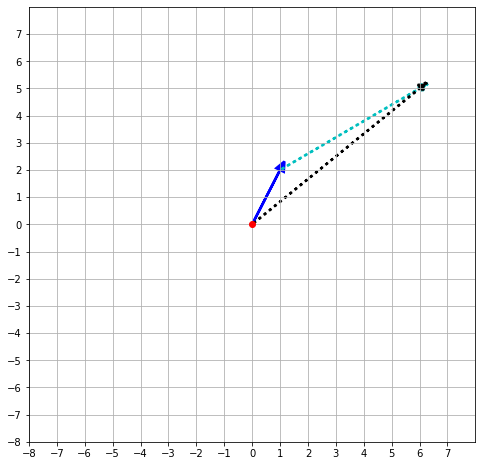

In [ ]:
# vector addition operation
vectors_plot(vector_1= np.array([1,2]), vector_2=np.array([5,3]))
# [6,5]

Result vector: [4 4]


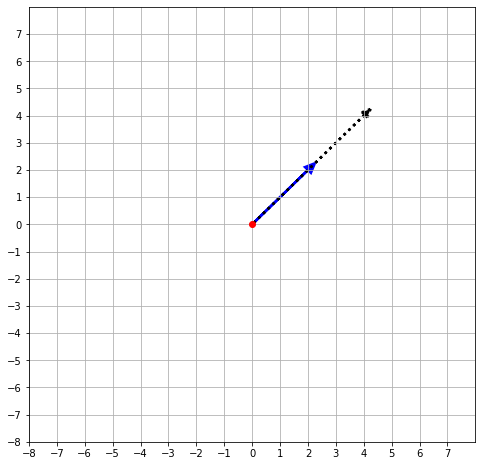

In [ ]:
# Multiplication operation
vectors_plot(vector_1= np.array([2,2]), scaler = 2)

Result vector: [3 1]


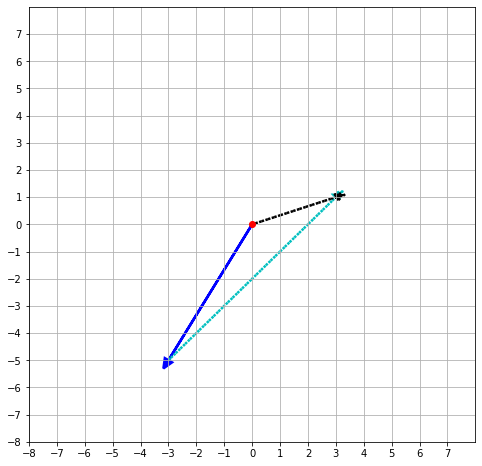

In [ ]:
# TODO 1 Add two vectors [-3, -5] and [2,2]
vectors_plot(vector_1= np.array([-3,-5]), vector_2=np.array([6,6]), scaler = None)


Result vector: [12  4]


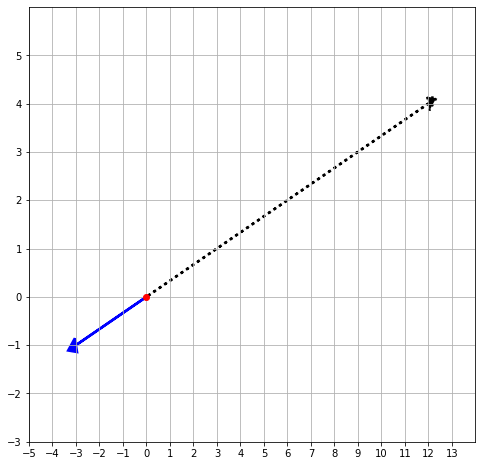

In [ ]:
# TODO 2 Multiply two vectors [-3, -1] and -2
vectors_plot(vector_1= np.array([-3,-1]), scaler = -4, xlim1=-5, xlim2=14, ylim1=-3, ylim2=6)
# (6, 2)

## Linear Combination

In this notebook you will learn how to solve linear combination problems using the python package [NumPy](http://www.numpy.org/) and its linear algebra subpackage [linalg](https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.linalg.html). This lab is provided to prepare you for the linear algebra you will be using in Neural Networks.

## Determining a Vector's span

From the lesson on linear combination, recall that the set of all possible vectors that you can reach with a linear combination of a given pair of vectors is called the span of those two vectors. Let's say we are given the pair of vectors $\vec{v}$ and $\vec{w}$, and we want to determine if a third vector $\vec{t}$ is within their span. If vector $\vec{t}$ is determined to be within their span, this means that $\vec{t}$ can be written as a linear combination of the pair of vectors $\vec{v}$ and $\vec{w}$.

This could be written as:

$\hspace{1cm}a\vec{v} + b\vec{w} = \vec{t}$,$\hspace{0.3cm}$where $\vec{v}$ and $\vec{w}$ are multiplied by scalars $a$ and $b$ and then added together to produce vector $\vec{t}$.

$\hspace{1.2cm}$*Equation 1*

This means if we can find a set of values for the scalars $a$ and $b$ that make *equation 1* true, then $\vec{t}$ is within the span of $\vec{v}$ and $\vec{w}$. Otherwise, if there is **no** set of values of the scalars $a$ and $b$ that make *equation 1* true, then $\vec{t}$ is **not** within their span.




We can determine a vector's span computationally using NumPy's linear algebra subpackage [linalg](https://docs.scipy.org/doc/numpy-1.13.0/reference/routines.linalg.html). Below we will go through an example below.

If the vectors have the following values:
    
$\hspace{1cm}\vec{v} = \begin{bmatrix} 1\\ 3\end{bmatrix}$
$\hspace{0.3cm}\vec{w} = \begin{bmatrix} 2\\ 5\end{bmatrix}$
$\hspace{0.3cm}\vec{t} = \begin{bmatrix} 4\\ 11\end{bmatrix}$    

We can rewrite $a\vec{v} + b\vec{w} = \vec{t}$ as:
    
$\hspace{1cm} a \begin{bmatrix} 1\\ 3\end{bmatrix} + b \begin{bmatrix} 2\\ 5\end{bmatrix} = \begin{bmatrix} 4\\ 11\end{bmatrix}$

In a linear algebra class you might have solved this problem by hand, using reduced row echelon form and rewriting *equation 1* as the augmented matrix. We have provided the augmented matrix for *equation 1* below.

$
\hspace{1cm}
\left[
\begin{array}{cc|c}
1 & 2  & 4 \\
3 & 5 & 11 \\
\end{array}
\right]
$

Notice that the augmented matrix's right side contains the vector $\vec{t}$. This is the vector that we are trying to determine if it's contained within the span of the other vectors, $\vec{v}$ and $\vec{w}$. Those other vectors whose span we are checking, compose the left side of the augmented matrix.

In [ ]:
def check_vector_span(set_of_vectors, vector_to_check):
    # Creates an empty vector of correct size
    vector_of_scalars = np.asarray([None]*set_of_vectors.shape[0])

    # Solves for the scalars that make the equation true if vector is within the span
    try:
        # TODO: Use np.linalg.solve() function here to solve for vector_of_scalars
        vector_of_scalars = np.linalg.solve(set_of_vectors, vector_to_check)
        if not (vector_of_scalars is None):
            print("\nVector is within span.\nScalars in s:", vector_of_scalars)

    # Handles the cases when the vector is NOT within the span
    except Exception as exception_type:
        if str(exception_type) == "Singular matrix":
            print("\nNo single solution\nVector is NOT within span")
        else:
            print("\nUnexpected Exception Error:", exception_type)
    return vector_of_scalars

In [ ]:
# Creates matrix t (right side of the augmented matrix).
t = np.array([4, 11])

# Creates matrix vw (left side of the augmented matrix).
vw = np.array([[1, 2], [3, 5]])

# Prints vw and t
print("\nMatrix vw:", vw, "\nVector t:", t, sep="\n")


Matrix vw:
[[1 2]
 [3 5]]

Vector t:
[ 4 11]


In [ ]:
# Call to check_vector_span to check vectors in Equation 1
# print("\nEquation 1:\n Matrix vw:", vw, "\nVector t:", t, sep="\n")
# s = check_vector_span(vw,t)

# Call to check a new set of vectors vw2 and t2
vw2 = np.array([[1, 2], [2, 4]])
t2 = np.array([6, 12])
# print("\nNew Vectors:\n Matrix vw2:", vw2, "\nVector t2:", t2, sep="\n")
# Call to check_vector_span
# s2 = check_vector_span(vw2,t2)

# Call to check a new set of vectors vw3 and t3
vw3 = np.array([[1, 2], [1, 2]])
t3 = np.array([6, 10])
print("\nNew Vectors:\n Matrix vw3:", vw3, "\nVector t3:", t3, sep="\n")
# Call to check_vector_span
s3 = check_vector_span(vw3,t3)




# [1, 2] [4]
# [3, 5] [11]   (2,1)   (2* 1) + (1 * 2) = 4    (2*3) + (1*5) = 11


New Vectors:
 Matrix vw3:
[[1 2]
 [1 2]]

Vector t3:
[ 6 10]

No single solution
Vector is NOT within span


### Solution for Checking *check_vector_span* by Solving for Scalars


You will notice that with *Equation 1*, $a\vec{v} + b\vec{w} = \vec{t}$, vector $\vec{t}$ was within the span of $\vec{v}$ and $\vec{w}$ such that scalars had the following values $a = 2$ and $b = 1$:
    
$\hspace{1cm} 2 \begin{bmatrix} 1\\ 3\end{bmatrix} + 1 \begin{bmatrix} 2\\ 5\end{bmatrix} = \begin{bmatrix} 4\\ 11\end{bmatrix}$

You will also notice that both the two new sets of vectors $\vec{t2}$ and $\vec{t3}$ were **not** within the span; such that, there were no value of the scalars that would provide a solution to the equation.



   

## Matrix

In [ ]:
mat1 = np.array([[3],[2],[6]])
mat2 = np.array([[-2], [6]])

In [ ]:
print(mat1.shape)
print(mat2.shape)

(3, 1)
(2, 1)


In [ ]:
np.add(mat1, mat2)

ValueError: ignored

In [ ]:
np.matmul(mat1,mat2)

ValueError: ignored

In [ ]:
m1 = np.array([
               [4,0],
               [0,5],
               [4,-1]
               ])
m2 = np.array([
               [4,0],
               [0,5],
               [4,-1]
               ])

In [ ]:
print(m1.shape)
print(m2.shape)

(3, 2)
(3, 2)


In [ ]:
np.add(m1, m2)

array([[ 8,  0],
       [ 0, 10],
       [ 8, -2]])

In [ ]:
m1

array([[ 4,  0],
       [ 0,  5],
       [ 4, -1]])

In [ ]:
m1.T

array([[ 4,  0,  4],
       [ 0,  5, -1]])

In [ ]:
print(m1.T.shape)
# print(m1)
# m1.T
np.matmul(m1.T, m2)

(2, 3)


array([[32, -4],
       [-4, 26]])

In [ ]:
a1 = np.array([
              [1,2,3],
              [4,5,6]
            ])
a1.shape

(2, 3)

In [ ]:
# l1= [1,2,3,4,5,6,7,8,9,10]

l1 = list(range(1,100000))

In [ ]:
a2= np.array([
    l1,
    l1,
    l1,
])
a2.shape

(3, 99999)

In [ ]:
np.matmul(a1, a2)

array([[      6,      12,      18, ...,  599982,  599988,  599994],
       [     15,      30,      45, ..., 1499955, 1499970, 1499985]])

In [ ]:
np.matmul(a1, a2).shape

(2, 99999)

In [ ]:
# TODO Find out the possbile mutiplication scenario of R, S , T , U matrix

R = np.array([[3,4], [6,8]])
R.shape

(2, 2)

In [ ]:
S = np.array([[2,1]])
S.shape

(1, 2)

In [ ]:
T = np.array([
    [9,7],
    [6,3],
    [5,2]
])
T.shape

(3, 2)

In [ ]:
U = S.T
U.shape

(2, 1)